# 🐍 ML with python (Class 8): Regression & Regularization

**Today's Journey:**
1. **Data Visualization:** Seeing the data with `matplotlib` and `seaborn`.
2. **Multivariate Linear Regression:** Drawing a hyperplane through our data.
3. **Polynomial Regression:** Drawing curves to capture complex patterns.
4. **Regularization (L1, L2, ElasticNet):** Taming our models to prevent them from "overthinking" (overfitting).

We are using the **California Housing Dataset** to predict median house values.

## 📦 1. Importing Libraries & Dataset
First, we load our tools and our data.

### STEP 1: Import core data science libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Ignore warnings for cleaner output during the session

In [ ]:
import warnings
warnings.filterwarnings('ignore')

Set a beautiful default plotting style

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### STEP 2: Import and load the dataset

In [ ]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target # Median House Value in $100,000s

### STEP 3: Inspect the data

In [ ]:
print(f"Dataset Shape: {df.shape} (Rows, Columns)")
display(df.head())

Dataset Shape: (20640, 9) (Rows, Columns)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 📊 2. Data Visualization & Insights
Before we predict anything, we need to look at our data. Machine Learning isn't magic; it's just math applied to these patterns.

### VISUALIZATION 1: Distribution of House Prices

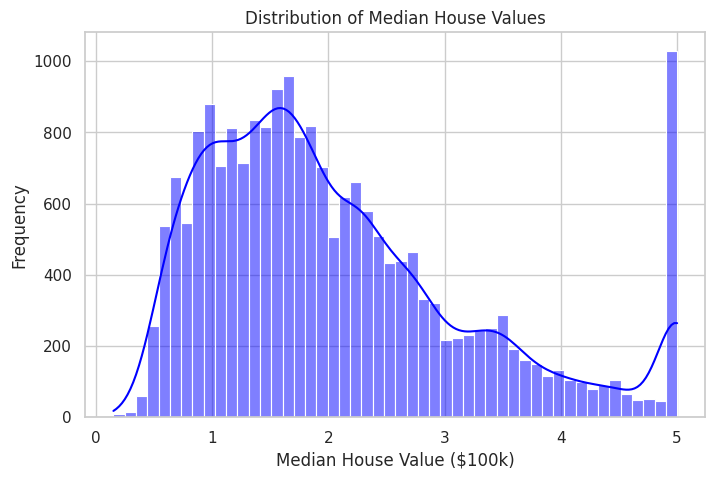

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Target'], bins=50, kde=True, color='blue')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Frequency')
plt.show()

### VISUALIZATION 2: Correlation Heatmap

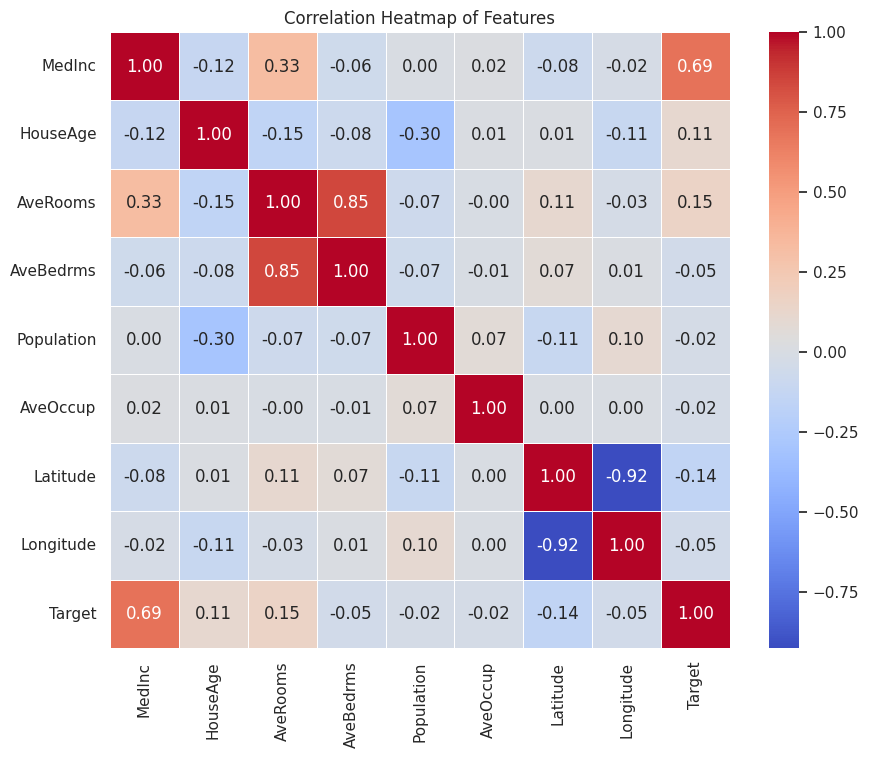

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

### 🔍 Insights from the Data:
1. **The Price Cap:** In the first chart, did you notice the weird spike at the far right ($500k)? The data collectors capped the maximum house price. Models might struggle with this artificial ceiling.
2. **The Best Predictor:** Look at the heatmap. The relationship between `MedInc` (Median Income) and `Target` is **0.69**. This is a strong positive correlation! People with higher incomes live in more expensive houses.
3. **Multicollinearity:** Notice `AveRooms` and `AveBedrms` have a correlation of **0.85**. They provide almost the same information. Giving both to a basic model can confuse it (we'll fix this later with Regularization!).

## ⚙️ 3. Data Preprocessing
We need to split our data into a "Study Guide" (Training Data) and a "Final Exam" (Testing Data).

**Crucial Step (Standardization):** Features have different scales (Income is a small decimal like 8.3, but Population is in the thousands). We scale them so every feature has a mean of 0 and a variance of 1. If we don't, our models will unfairly assume that "Population" is more important just because the numbers are bigger.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### STEP 1: Separate Features (X) and Target (y)

In [ ]:
X = df.drop('Target', axis=1)
y = df['Target']

### STEP 2: Train-Test Split (80% Training, 20% Testing)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### STEP 3: Scale the Data

In [ ]:
scaler = StandardScaler()

### We FIT the scaler ONLY on training data to prevent cheating (data leakage)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data is split and scaled! Ready for modeling.")

Data is split and scaled! Ready for modeling.


In [ ]:
X_train_scaled

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]])

In [ ]:
scaler = StandardScaler()

## 📏 Understanding Evaluation Parameters
Before we make a model, how do we grade it? We use two main scores:

1. **RMSE (Root Mean Squared Error):** This is the "Average Mistake" in the same units as our target.
   * *Example:* If our RMSE is 0.70, it means our predictions are off by an average of 0.70 units. Since our target is in \$100k, we are off by \$70,000 on average. **Lower is better!**
2. **R-Squared (R2 Score):** This is like a test grade from 0 to 1 (or 0% to 100%). It tells us how much of the house price is explained by our input data.
   * *Example:* An R2 of 0.60 means our model explains 60% of why house prices go up or down. **Higher is better!**

## 📈 4. Multivariate Linear Regression
**The Concept:** The model tries to draw a straight, flat line (or flat plane in 3D) through the data to connect the features to the price. It gives a "weight" (coefficient) to every feature.

**The Equation:**
$$\hat{Y} = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_nX_n$$
- $\hat{Y}$ is the predicted house price.
- $\beta_0$ is the intercept (base price).
- $\beta_1, \beta_2...$ are the coefficients (weights) learned by the model.
- $X_1, X_2...$ are the input features (e.g., Income, Rooms).

**The Cost Function (Mean Squared Error - MSE):**
The model learns by minimizing the error between its predictions and the actual prices:
$$J(\beta) = \frac{1}{N} \sum_{i=1}^{N} (Y_i - \hat{Y}_i)^2$$

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Initialize and Train

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

### Predict on the unseen "Exam" data

In [ ]:
lr_preds = lr_model.predict(X_test_scaled)
# Grade the model
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print(f"--- Linear Regression Performance ---")
print(f"RMSE: {lr_rmse:.4f} (Average error: ${lr_rmse*100000:,.0f})")
print(f"R2:   {lr_r2:.4f} (Explains {lr_r2*100:.1f}% of the data)")

# Save coefficients for later
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Linear_Reg': lr_model.coef_})

--- Linear Regression Performance ---
RMSE: 0.7456 (Average error: $74,558)
R2:   0.5758 (Explains 57.6% of the data)


In [ ]:
coefficients_df

,Feature,Linear_Reg
0,MedInc,0.854383
1,HouseAge,0.122546
2,AveRooms,-0.294410
3,AveBedrms,0.339259
4,Population,-0.002308
5,AveOccup,-0.040829
6,Latitude,-0.896929
7,Longitude,-0.869842


### 💡 Model Insight:
Linear Regression gave us a baseline. Being off by ~$74,000 on average isn't terrible, but it's not great. The real world isn't always a straight line! What if the relationship between house age and price curves over time?

## 🎢 5. Polynomial Regression
**The Concept:** Instead of just drawing a straight line, we allow the model to draw curves.

We do this by creating *new* features. If we have features $X_1$ and $X_2$, a degree=2 polynomial adds squared terms and interaction terms.

**The Equation (Degree 2 for two features):**
$$\hat{Y} = \beta_0 + \beta_1X_1 + \beta_2X_2 + \beta_3X_1^2 + \beta_4X_2^2 + \beta_5(X_1X_2)$$
- $X_1^2, X_2^2$ allow the model to curve.
- $X_1X_2$ captures "interaction" (e.g., does high income *combined* with new houses cause a disproportionate price jump?).

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

### STEP 1: Create the Polynomial feature generator

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)

### STEP 2: Transform our standard features into squared/interacting features

In [ ]:
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]} (Includes squares and interactions!)\n")

Original features: 8
Polynomial features: 44 (Includes squares and interactions!)



### STEP 3: Train a Linear Regression model on the NEW curvy features

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_preds = poly_model.predict(X_test_poly)

### STEP 4: Grade the model

In [89]:
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_preds))
poly_r2 = r2_score(y_test, poly_preds)

print(f"--- Polynomial Regression (Degree 2) Performance ---")
print(f"RMSE: {poly_rmse:.4f} (Average error: ${poly_rmse*100000:,.0f})")
print(f"R2:   {poly_r2:.4f} (Explains {poly_r2*100:.1f}% of the data)")

--- Polynomial Regression (Degree 2) Performance ---
RMSE: 0.6814 (Average error: $68,140)
R2:   0.6457 (Explains 64.6% of the data)


### 💡 Model Insight:
Look at that R2 score jump! By allowing the model to find curves and interactions (like Income $\times$ Rooms), it fit the data much better.

**The Danger:** Polynomial Regression creates *a lot* of features (jumped from 8 to 44). Too many features can lead to **Overfitting** (memorizing the training data but failing in the real world). This is exactly why we need Regularization!

# **Class 09**

## 🛡️ 6. Regularization Theory (Fixing Overfitting)

Regularization adds a "penalty" to the Cost Function. It tells the model: *"You can use these features, but I will fine you if your weights (coefficients) get too big."* This keeps the model simple and generalizable.

*(Note: We will apply these to our original 8 features so we can easily plot and compare them).*

### 🔴 Ridge Regression (L2)
**Analogy:** Think of Ridge as putting a rubber band on the coefficients. They can stretch, but the rubber band pulls them back toward zero. They rarely reach exactly zero.

**The Equation:**
$$Cost = MSE + \alpha \sum_{j=1}^{p} \beta_j^2$$
- Adds a penalty equal to the **square** of the magnitude of coefficients.
- $\alpha$ (alpha) controls the penalty strength. Higher $\alpha$ = tighter rubber band.

**Effect:** Shrinks all weights smoothly. Great for handling highly correlated features (like our Rooms and Bedrooms).

In [90]:
from sklearn.linear_model import Ridge

# We use a high alpha (=100) here to force a strong rubber band, just to show the effect visually later.
ridge_model = Ridge(alpha=100.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

print(f"--- Ridge (L2) Performance ---")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R2: {ridge_r2:.4f}")

coefficients_df['Ridge (L2)'] = ridge_model.coef_

--- Ridge (L2) Performance ---
RMSE: 0.7438
R2: 0.5778


### 🔵 Lasso Regression (L1)
**Analogy:** Think of Lasso as a strict budget or a bouncer. If a feature isn't contributing significantly, its weight is kicked out (forced exactly to 0.0).

**The Equation:**
$$Cost = MSE + \alpha \sum_{j=1}^{p} |\beta_j|$$
- Adds a penalty equal to the **absolute** value of the magnitude of coefficients.

**Effect:** Feature Selection! It creates a simpler model by dropping useless features completely.

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1) # Small alpha because Lasso is very strict
lasso_model.fit(X_train_scaled, y_train)
lasso_preds = lasso_model.predict(X_test_scaled)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))
lasso_r2 = r2_score(y_test, lasso_preds)

print(f"--- Lasso (L1) Performance ---")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"R2: {lasso_r2:.4f}")

coefficients_df['Lasso (L1)'] = lasso_model.coef_
print("\nLook below: Lasso threw away multiple features (made them exactly 0.0)!")
display(coefficients_df)

--- Lasso (L1) Performance ---
RMSE: 0.8244
R2: 0.4814

Look below: Lasso threw away multiple features (made them exactly 0.0)!


,Feature,Linear_Reg,Ridge (L2),Lasso (L1)
0,MedInc,0.854383,0.848139,0.710598
1,HouseAge,0.122546,0.129512,0.106453
2,AveRooms,-0.294410,-0.274522,-0.000000
3,AveBedrms,0.339259,0.314804,0.000000
4,Population,-0.002308,-0.000024,-0.000000
5,AveOccup,-0.040829,-0.041133,-0.000000
6,Latitude,-0.896929,-0.827628,-0.011469
7,Longitude,-0.869842,-0.799554,-0.000000


### 🟣 ElasticNet
**The Concept:** The best of both worlds. It combines the bouncer (Lasso) and the rubber band (Ridge). The `l1_ratio` parameter (e.g., 0.5) means it is 50% Lasso and 50% Ridge.

**The Equation:**
$$Cost = MSE + \alpha \left( r \sum_{j=1}^{p} |\beta_j| + \frac{1 - r}{2} \sum_{j=1}^{p} \beta_j^2 \right)$$
- $r$ is the `l1_ratio` (mix between L1 and L2 penalties).

In [91]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_model.fit(X_train_scaled, y_train)
elastic_preds = elastic_model.predict(X_test_scaled)

elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_preds))
elastic_r2 = r2_score(y_test, elastic_preds)

print(f"--- ElasticNet Performance ---")
print(f"RMSE: {elastic_rmse:.4f}")
print(f"R2: {elastic_r2:.4f}")

coefficients_df['ElasticNet'] = elastic_model.coef_

--- ElasticNet Performance ---
RMSE: 0.7974
R2: 0.5148


## 🔍 7. Visualizing the Coefficient Weights
Let's visualize how the Regularization models changed the importance (weights) of our original 8 features compared to basic Linear Regression.

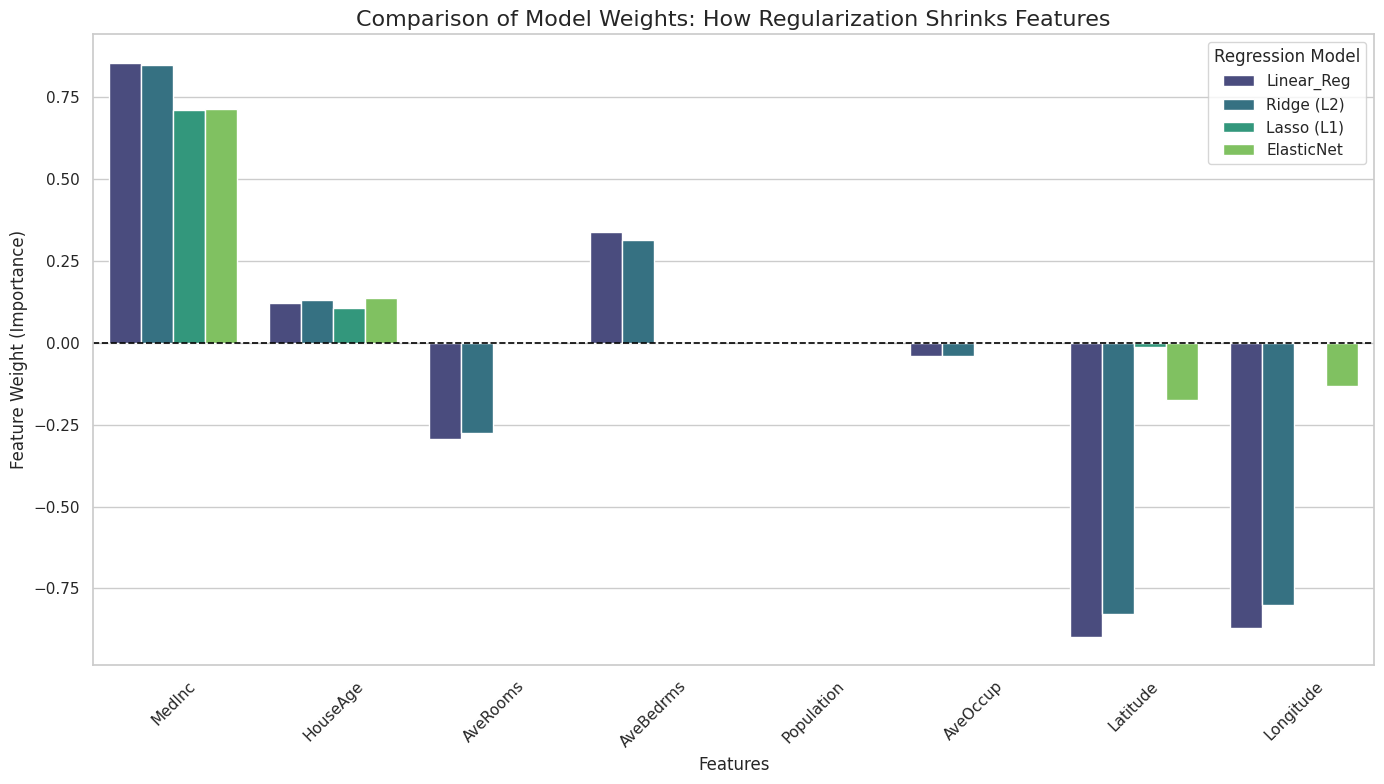

In [ ]:
# Formatting the dataframe for seaborn
coef_melted = coefficients_df.melt(id_vars="Feature",
                                   var_name="Model",
                                   value_name="Coefficient Value")

plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Coefficient Value', hue='Model', data=coef_melted, palette="viridis")
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.title('Comparison of Model Weights: How Regularization Shrinks Features', fontsize=16)
plt.ylabel('Feature Weight (Importance)', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.legend(title='Regression Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###💡 VISUAL INSIGHTS:
- Linear Regression (Dark Purple): Gives massive weights to features.
- Ridge (Blue): Kept all features but shrunk the tall purple bars downward.
- Lasso (Teal): Completely deleted 'AveBedrms' and 'Population' (bars are at exactly 0)!

## 🏆 8. Final Model Leaderboard & Prediction
Let's stack all our models side-by-side, including our powerful Polynomial model.

### 1. Summary DataFrame

In [ ]:
metrics_data = {
    'Model': ['Standard Linear', 'Polynomial (Deg 2)', 'Ridge (L2)', 'Lasso (L1)', 'ElasticNet'],
    'RMSE ($100k)': [lr_rmse, poly_rmse, ridge_rmse, lasso_rmse, elastic_rmse],
    'R2 Score (0 to 1)': [lr_r2, poly_r2, ridge_r2, lasso_r2, elastic_r2]
}
metrics_df = pd.DataFrame(metrics_data)
print("=== MODEL PERFORMANCE LEADERBOARD ===")
display(metrics_df.sort_values(by='RMSE ($100k)'))

=== MODEL PERFORMANCE LEADERBOARD ===


,Model,RMSE ($100k),R2 Score (0 to 1)
1,Polynomial (Deg 2),0.681397,0.645682
2,Ridge (L2),0.743819,0.577791
0,Standard Linear,0.745581,0.575788
4,ElasticNet,0.797406,0.514765
3,Lasso (L1),0.824396,0.481361


### 2. Making a Real Prediction

In [ ]:
print("\n=== 🏠 PREDICTING A NEW HOUSE PRICE ===")

# Let's use our Polynomial model (our winner!) to predict the first house in the test set
single_house_poly_features = X_test_poly[0].reshape(1, -1)
actual_value = y_test.iloc[0]

predicted_value = poly_model.predict(single_house_poly_features)[0]

print(f"Actual House Value:    ${actual_value * 100000:,.2f}")
print(f"Model Predicted Value: ${predicted_value * 100000:,.2f}")
print(f"Difference:            ${abs(actual_value - predicted_value) * 100000:,.2f}")


=== 🏠 PREDICTING A NEW HOUSE PRICE ===
Actual House Value:    $47,700.00
Model Predicted Value: $55,399.74
Difference:            $7,699.74
